# Telecom X — Customer Churn: Exploratory Data Analysis

## Introduction

This project studies customer churn at Telecom X: which customers cancel, and what distinguishes them from customers who stay.

Pipeline: extract nested JSON from the source URL, clean and normalize it with pandas, run exploratory analysis (distributions, segment rates, boxplots, correlations), and export a cleaned CSV for modeling.

The modeling stage lives in [telecomx-churn-prediction](https://github.com/MarlonPC32/telecomx-churn-prediction).

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df = pd.read_json(url)
print(df.shape)
df.head()

(7267, 6)


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   str   
 1   Churn       7267 non-null   str   
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(4), str(2)
memory usage: 340.8+ KB


In [3]:
df["Churn"].value_counts(dropna=False)

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

In [4]:
df.isnull().sum().sort_values(ascending=False).head(10)

customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64

### Initial observations

- `customer`, `phone`, `internet`, and `account` hold nested dictionaries — the JSON needs flattening before analysis.
- The target `Churn` has three distinct values: `"Yes"`, `"No"`, and blank (224 records, 3.1%). **Blank is not "No"** — those records carry no label information and must be excluded from supervised analysis, not relabeled.
- `Charges.Total` arrives as strings and will need numeric conversion.

## Cleaning and normalization

In [5]:
# Flatten nested JSON columns
customer = pd.json_normalize(df["customer"])
phone = pd.json_normalize(df["phone"])
internet = pd.json_normalize(df["internet"])
account = pd.json_normalize(df["account"])

df = pd.concat([df.drop(columns=["customer", "phone", "internet", "account"]),
                customer, phone, internet, account], axis=1)
print(df.shape)
df.columns.tolist()

(7267, 21)


['customerID',
 'Churn',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Charges.Monthly',
 'Charges.Total']

In [6]:
# Normalize inconsistent string categories
for col in ["InternetService", "Contract", "PaymentMethod"]:
    df[col] = df[col].str.strip().str.lower()
df["Churn"] = df["Churn"].str.strip().str.lower()

In [7]:
# Charges.Total arrives as strings; coerce to numeric
df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")
print("nulls in Charges.Total:", df["Charges.Total"].isnull().sum())
print(df.loc[df["Charges.Total"].isnull(), "tenure"].describe())

nulls in Charges.Total: 11
count    11.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64


In [8]:
# The nulls are all tenure-0 customers (no billing history yet) -> 0 is defensible and documented
df["Charges.Total"] = df["Charges.Total"].fillna(0)

In [9]:
# TARGET HANDLING (correction): map known labels, then EXCLUDE unknowns.
# Earlier versions of this analysis mapped blanks to 0 (retained), which fabricates
# negative labels. Unknown outcomes cannot be used for supervised learning.
df["Churn"] = df["Churn"].map({"yes": 1, "no": 0})
n_unknown = df["Churn"].isnull().sum()
print(f"records with unknown churn label: {n_unknown} ({n_unknown/len(df):.1%}) -> excluded")
df = df.dropna(subset=["Churn"]).copy()
df["Churn"] = df["Churn"].astype(int)
print("final shape:", df.shape)
print(df["Churn"].value_counts(normalize=True).round(4))

records with unknown churn label: 224 (3.1%) -> excluded
final shape: (7043, 21)
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [10]:
# Feature engineering: estimated daily spend.
# NOTE: this is exactly Charges.Monthly / 30 (correlation 1.0 with the monthly column).
# Kept here for exploration, but NOT used as a model feature later — it adds no information
# beyond the monthly charge and would only fragment feature-importance scores.
df["Cuentas_Diarias"] = df["Charges.Monthly"] / 30
df[["Charges.Monthly", "Cuentas_Diarias"]].head()

,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


## Exploratory analysis

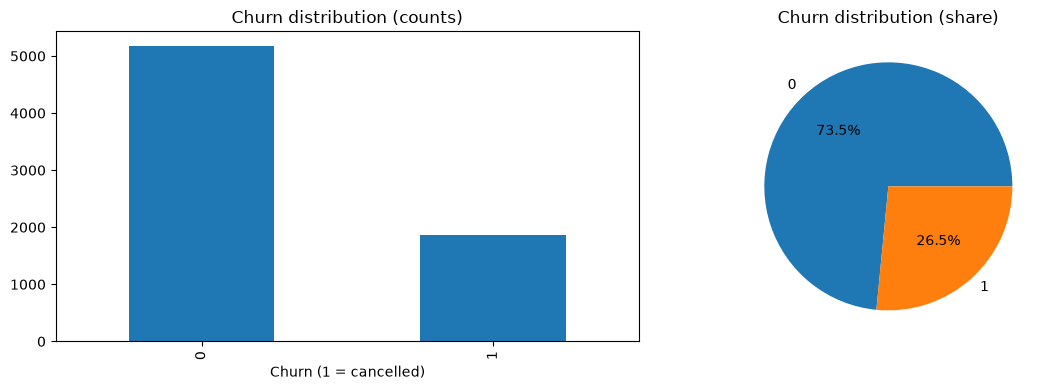

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["Churn"].value_counts().plot(kind="bar", ax=ax[0])
ax[0].set_title("Churn distribution (counts)")
ax[0].set_xlabel("Churn (1 = cancelled)")
df["Churn"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax[1])
ax[1].set_title("Churn distribution (share)")
ax[1].set_ylabel("")
plt.tight_layout()
plt.show()

In [12]:
# Segment RATES (not raw counts): within-segment churn share + segment size
for col in ["Contract", "PaymentMethod", "gender"]:
    ct = pd.crosstab(df[col], df["Churn"], normalize="index").round(3)
    ct["n"] = pd.crosstab(df[col], df["Churn"])[0] + pd.crosstab(df[col], df["Churn"])[1]
    print(f"--- churn rate by {col} ---")
    print(ct)
    print()

--- churn rate by Contract ---
Churn               0      1     n
Contract                          
month-to-month  0.573  0.427  3875
one year        0.887  0.113  1473
two year        0.972  0.028  1695

--- churn rate by PaymentMethod ---
Churn                          0      1     n
PaymentMethod                                
bank transfer (automatic)  0.833  0.167  1544
credit card (automatic)    0.848  0.152  1522
electronic check           0.547  0.453  2365
mailed check               0.809  0.191  1612

--- churn rate by gender ---
Churn       0      1     n
gender                    
Female  0.731  0.269  3488
Male    0.738  0.262  3555



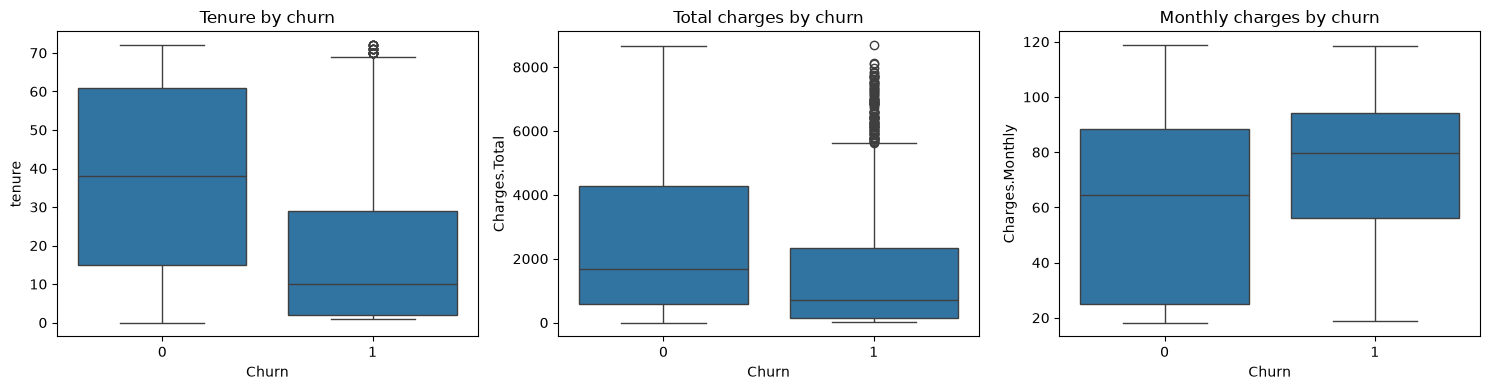

In [13]:
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x="Churn", y="tenure", data=df, ax=ax[0]); ax[0].set_title("Tenure by churn")
sns.boxplot(x="Churn", y="Charges.Total", data=df, ax=ax[1]); ax[1].set_title("Total charges by churn")
sns.boxplot(x="Churn", y="Charges.Monthly", data=df, ax=ax[2]); ax[2].set_title("Monthly charges by churn")
plt.tight_layout()
plt.show()

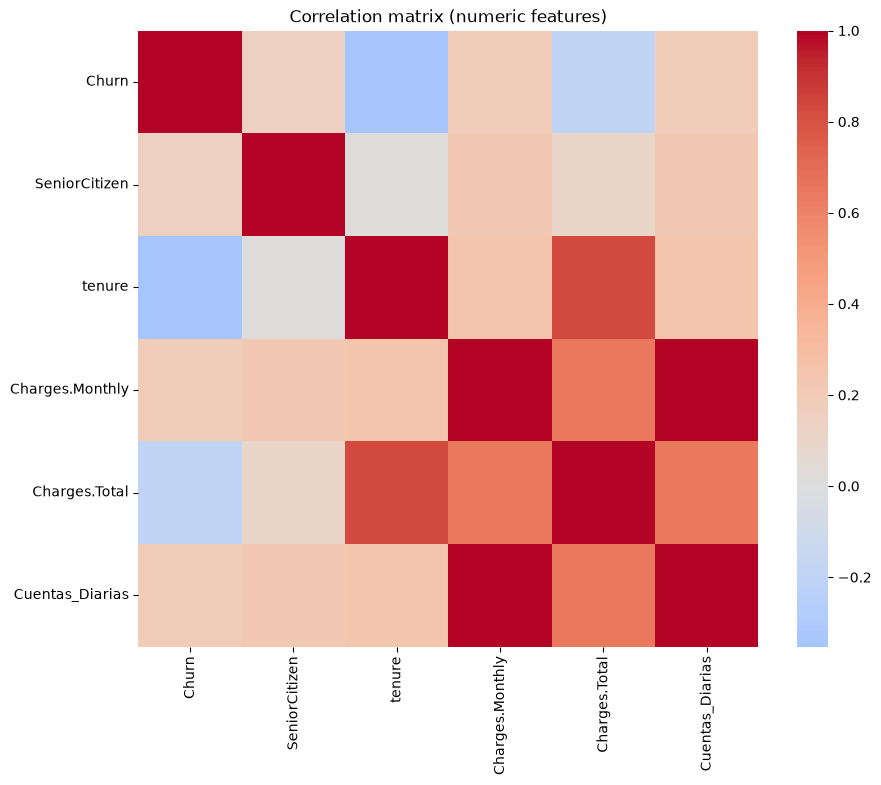

Churn              1.000
Charges.Monthly    0.193
Cuentas_Diarias    0.193
SeniorCitizen      0.151
Charges.Total     -0.198
tenure            -0.352
Name: Churn, dtype: float64


In [14]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric features)")
plt.show()
print(corr["Churn"].sort_values(ascending=False).head(8).round(3))

## Findings

- Churn is not uniform: 26.5% of labeled customers cancelled (7,043 records after excluding 224 unlabeled).
- Contract length is the sharpest categorical split — month-to-month customers churn at far higher rates than one- and two-year customers (segment rates, not raw counts).
- Electronic-check payers churn more than automatic or mailed-check payers.
- Tenure separates the classes clearly (correlation with churn: -0.35): churned customers concentrate at low tenure — the early months are the risk window.
- Monthly charges correlate positively (+0.19) and total charges negatively (-0.20) with churn in this snapshot.
- `Cuentas_Diarias` correlates 1.00 with monthly charges — a pure rescale, excluded from modeling.

## Export: cleaned modeling dataset

The prediction notebook consumes this file. It is generated here so the handoff is reproducible — no hand-copied CSVs.

In [15]:
df.to_csv("telecomx_datos_tratados.csv", index=False)
print("exported telecomx_datos_tratados.csv:", df.shape)
# sanity check on reload
chk = pd.read_csv("telecomx_datos_tratados.csv")
print("reload ok:", chk.shape, "| churn rate:", round(chk["Churn"].mean(), 4))

exported telecomx_datos_tratados.csv: (7043, 22)
reload ok: (7043, 22) | churn rate: 0.2654


## Notes and limitations

- 224 records (3.1%) were excluded for unknown churn labels; all reported rates use the 7,043 labeled records.
- `Charges.Total` nulls (tenure-0 customers) were set to 0 and documented above.
- This is a single snapshot — there is no defined scoring date or future churn horizon, so the follow-up model classifies this snapshot rather than operating as a validated early-warning system.
- Built for the Telecom X Data Science Challenge (Oracle Next Education).